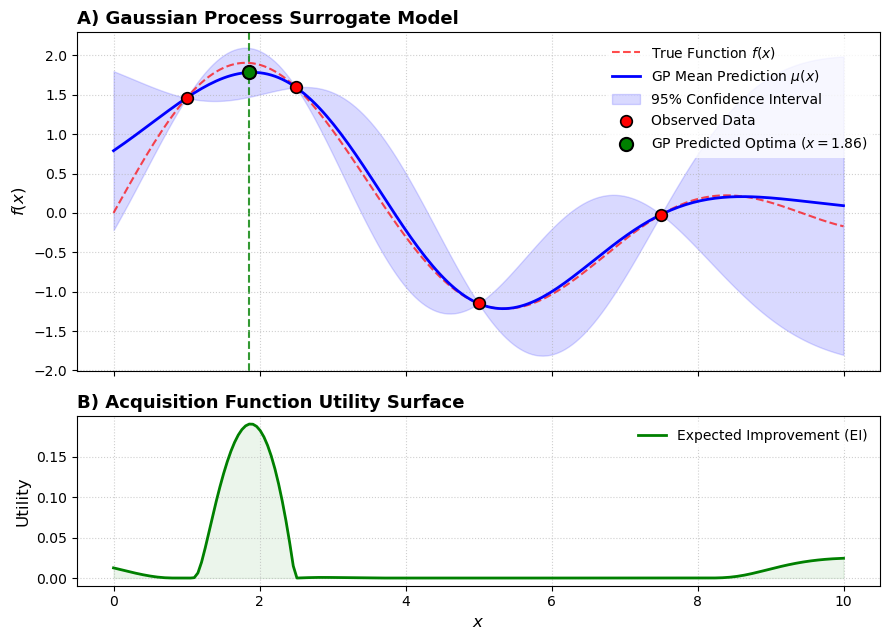

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. DEFINE THE TRUE TARGET FUNCTION (The "expensive" function we want to optimize)
def true_func(x):
    return np.sin(x) + np.sin(2.0 * x / 3.0)

# 2. DEFINE THE SQUARED EXPONENTIAL (RBF) KERNEL
def rbf_kernel(x1, x2, l=1.5, sigma_f=1.0):
    """
    Computes the covariance matrix between two arrays of points.
    l: lengthscale (controls horizontal smoothness)
    sigma_f: output variance (controls vertical scale)
    """
    dist_matrix = np.sum(x1**2, 1).reshape(-1, 1) + np.sum(x2**2, 1) - 2 * np.dot(x1, x2.T)
    return sigma_f**2 * np.exp(-0.5 / l**2 * dist_matrix)

# 3. GAUSSIAN PROCESS POSTERIOR CALCULATIONS
def gp_prediction(X_train, y_train, X_test, l=1.5, sigma_f=1.0, sigma_n=1e-4):
    """Calculates the posterior mean and standard deviation at test points."""
    K = rbf_kernel(X_train, X_train, l, sigma_f) + sigma_n**2 * np.eye(len(X_train))
    K_s = rbf_kernel(X_train, X_test, l, sigma_f)
    K_ss = rbf_kernel(X_test, X_test, l, sigma_f) + 1e-8 * np.eye(len(X_test))
    
    K_inv = np.linalg.inv(K)
    
    mu_s = K_s.T.dot(K_inv).dot(y_train)
    cov_s = K_ss - K_s.T.dot(K_inv).dot(K_s)
    
    return mu_s.flatten(), np.sqrt(np.diag(cov_s))

# 4. EXPECTED IMPROVEMENT (EI) ACQUISITION FUNCTION
def expected_improvement(mu, sigma, y_max, xi=0.01):
    """Computes EI utility surface to balance exploration/exploitation."""
    sigma = np.maximum(sigma, 1e-9)  # Avoid division by zero
    improvement = mu - y_max - xi
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# =====================================================================
# DATA SETUP & RUNTIME
# =====================================================================

# 4 initial observed coordinates (training data)
X_train = np.array([[1.0], [2.5], [5.0], [7.5]])
y_train = true_func(X_train).flatten()

# 200 evenly spaced points across the space to predict/plot
X_test = np.linspace(0, 10, 200).reshape(-1, 1)

# Fit GP and calculate acquisition values
mu, sigma = gp_prediction(X_train, y_train, X_test)
y_max = np.max(y_train)
ei = expected_improvement(mu, sigma, y_max)

# Locate the maximum point on the acquisition surface
idx_next = np.argmax(ei)
next_x = X_test[idx_next]
next_x_scalar = next_x.item()  # Safe scalar extraction for plotting text

# =====================================================================
# PLOTTING STYLES (Generates the report-ready layout)
# =====================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6.5), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Top Subplot: GP Model and Uncertainty Bars
ax1.plot(X_test, true_func(X_test), 'r--', label='True Function $f(x)$', alpha=0.7, linewidth=1.5)
ax1.plot(X_test, mu, 'b-', label='GP Mean Prediction $\mu(x)$', linewidth=2)
ax1.fill_between(X_test.flatten(), mu - 1.96 * sigma, mu + 1.96 * sigma, color='blue', alpha=0.15, label='95% Confidence Interval')
ax1.scatter(X_train, y_train, color='red', marker='o', s=70, edgecolors='black', linewidths=1.2, zorder=5, label='Observed Data')

# UPDATED: Vertical reference line and target marker changed to match the green acquisition function surface
ax1.axvline(next_x_scalar, color='green', linestyle='--', linewidth=1.5, alpha=0.8, zorder=1)
ax1.scatter([next_x_scalar], [mu[idx_next]], color='green', marker='o', s=90, edgecolors='black', linewidths=1.5, zorder=6, label=f'GP Predicted Optima ($x={next_x_scalar:.2f}$)')

ax1.set_ylabel('$f(x)$', fontsize=12)
ax1.set_title('A) Gaussian Process Surrogate Model', fontsize=13, fontweight='bold', loc='left')
ax1.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
ax1.grid(True, linestyle=':', alpha=0.6)

# Bottom Subplot: Acquisition Function / Utility Surface
ax2.plot(X_test, ei, 'g-', label='Expected Improvement (EI)', linewidth=2)
ax2.fill_between(X_test.flatten(), 0, ei, color='green', alpha=0.08)

# UPDATED: Cyan line, circle, and legend reference removed from the utility surface plot

ax2.set_xlabel('$x$', fontsize=12)
ax2.set_ylabel('Utility', fontsize=12)
ax2.set_title('B) Acquisition Function Utility Surface', fontsize=13, fontweight='bold', loc='left')
ax2.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


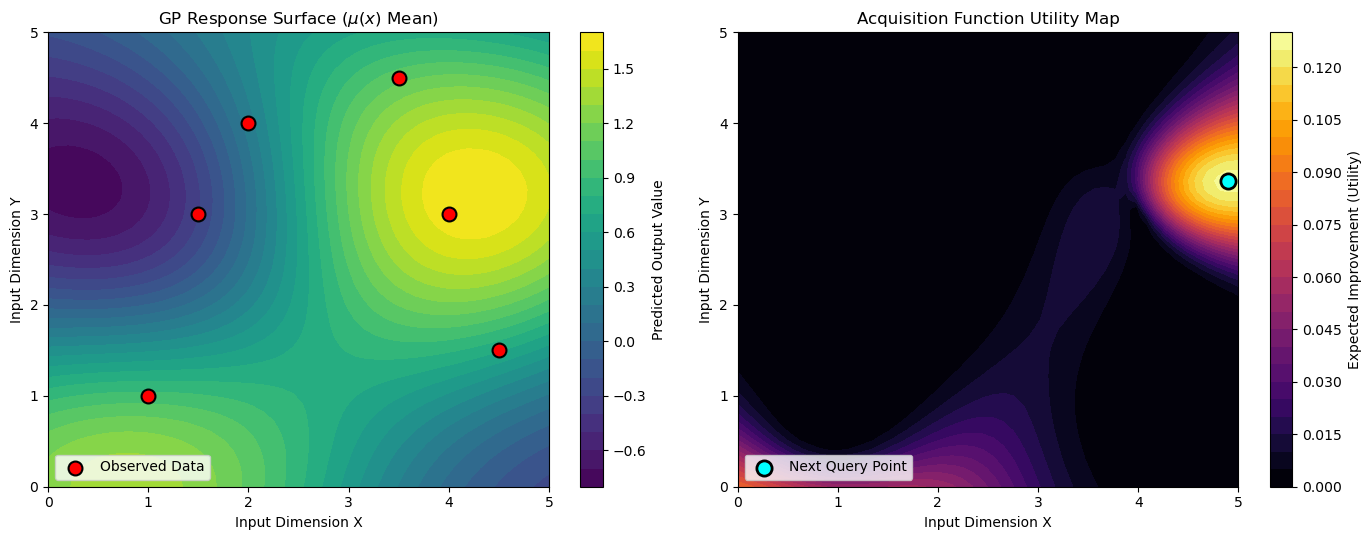

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. DEFINE THE 2D TRUE OBJECTIVE FUNCTION (A response surface landscape)
def true_func_2d(X, Y):
    # Generates an interesting hilly surface with peaks and valleys
    return np.sin(X) * np.cos(Y) + np.sin(X / 2)

# 2. 2D SQUARED EXPONENTIAL (RBF) KERNEL
def rbf_kernel_2d(X1, X2, l=1.5, sigma_f=1.0):
    """Computes covariance matrix for 2D coordinate points."""
    # Distance calculation extended to handle multi-dimensional inputs
    dist_matrix = np.sum(X1**2, 1).reshape(-1, 1) + np.sum(X2**2, 1) - 2 * np.dot(X1, X2.T)
    return sigma_f**2 * np.exp(-0.5 / l**2 * dist_matrix)

# 3. 2D GAUSSIAN PROCESS POSTERIOR 
def gp_prediction_2d(X_train, y_train, X_test, l=1.8, sigma_f=1.0, sigma_n=1e-4):
    K = rbf_kernel_2d(X_train, X_train, l, sigma_f) + sigma_n**2 * np.eye(len(X_train))
    K_s = rbf_kernel_2d(X_train, X_test, l, sigma_f)
    K_ss = rbf_kernel_2d(X_test, X_test, l, sigma_f) + 1e-8 * np.eye(len(X_test))
    
    K_inv = np.linalg.inv(K)
    mu_s = K_s.T.dot(K_inv).dot(y_train)
    cov_s = K_ss - K_s.T.dot(K_inv).dot(K_s)
    
    return mu_s.flatten(), np.sqrt(np.diag(cov_s))

# 4. EXPECTED IMPROVEMENT FOR THE SURFACE
def expected_improvement(mu, sigma, y_max, xi=0.01):
    sigma = np.maximum(sigma, 1e-9)
    improvement = mu - y_max - xi
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# =====================================================================
# DATA & GRID SETUP
# =====================================================================
np.random.seed(12)

# 6 initial observed sample coordinates in 2D space [x, y]
X_train = np.array([
    [1.0, 1.0], [2.0, 4.0], [4.5, 1.5], 
    [3.5, 4.5], [1.5, 3.0], [4.0, 3.0]
])
y_train = true_func_2d(X_train[:, 0], X_train[:, 1])

# Create a dense 2D test grid (50x50 resolution) to evaluate the surfaces
x_coord = np.linspace(0, 5, 50)
y_coord = np.linspace(0, 5, 50)
X_mesh, Y_mesh = np.meshgrid(x_coord, y_coord)
X_test = np.vstack([X_mesh.ravel(), Y_mesh.ravel()]).T

# Run predictions across the whole surface landscape
mu, sigma = gp_prediction_2d(X_train, y_train, X_test)
y_max = np.max(y_train)
ei = expected_improvement(mu, sigma, y_max)

# Reshape flattened output arrays back into 2D grid shapes for plotting
mu_surface = mu.reshape(X_mesh.shape)
sigma_surface = sigma.reshape(X_mesh.shape)
ei_surface = ei.reshape(X_mesh.shape)

# Find the highest utility point on the acquisition surface
idx_next = np.argmax(ei)
next_x, next_y = X_test[idx_next]

# =====================================================================
# SIDE-BY-SIDE PLOTTING
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Plot 1: The GP Predicted Response Surface Mean
contour1 = ax1.contourf(X_mesh, Y_mesh, mu_surface, levels=25, cmap='viridis')
fig.colorbar(contour1, ax=ax1, label='Predicted Output Value')
# CHANGED: Overlay known data points as RED circles with a black border
ax1.scatter(X_train[:, 0], X_train[:, 1], color='red', marker='o', s=100, edgecolors='black', linewidths=1.5, zorder=5, label='Observed Data')
ax1.set_title('GP Response Surface ($\mu(x)$ Mean)')
ax1.set_xlabel('Input Dimension X')
ax1.set_ylabel('Input Dimension Y')
ax1.legend(loc='lower left')

# Plot 2: The Acquisition Function Utility Surface
contour2 = ax2.contourf(X_mesh, Y_mesh, ei_surface, levels=25, cmap='inferno')
fig.colorbar(contour2, ax=ax2, label='Expected Improvement (Utility)')
# Highlight the next exact coordinate to sample
ax2.scatter(next_x, next_y, color='cyan', marker='o', s=120, edgecolors='black', linewidths=2, zorder=6, label='Next Query Point')
ax2.set_title('Acquisition Function Utility Map')
ax2.set_xlabel('Input Dimension X')
ax2.set_ylabel('Input Dimension Y')
ax2.legend(loc='lower left')

plt.tight_layout()
plt.show()


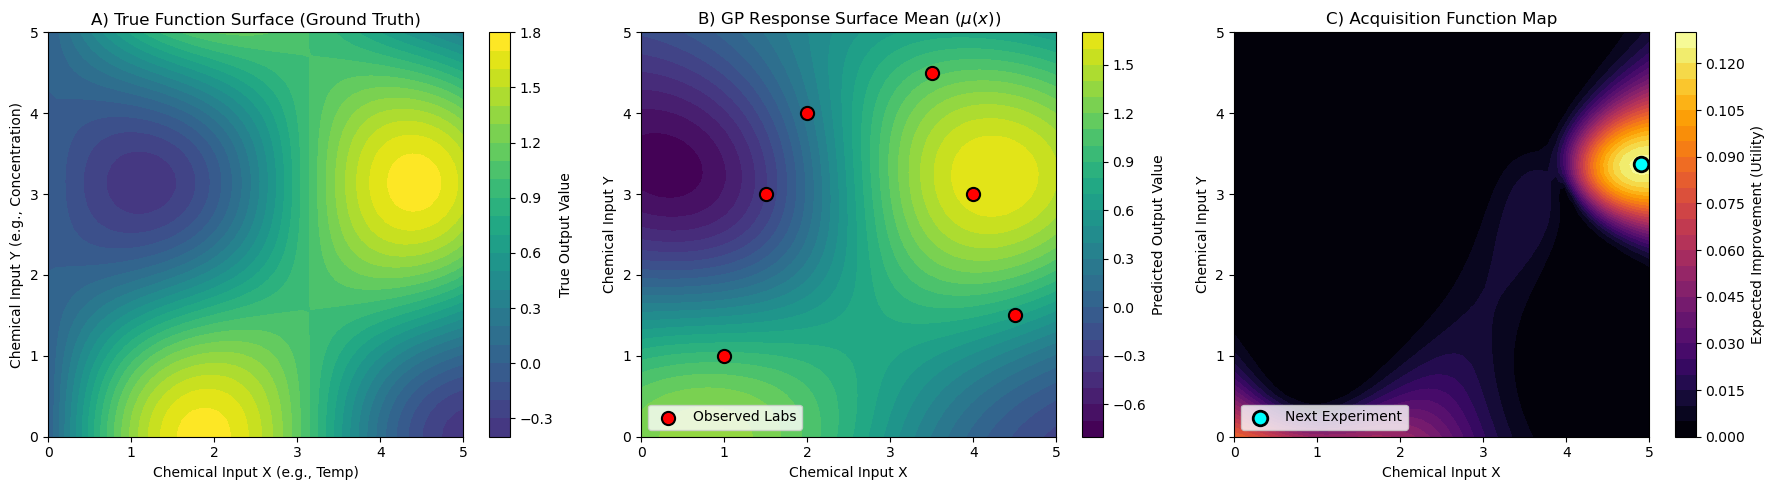

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. DEFINE THE 2D TRUE OBJECTIVE FUNCTION (The actual chemical reaction surface)
def true_func_2d(X, Y):
    # Generates a hilly landscape (e.g., Yield % vs Temperature & Concentration)
    return np.sin(X) * np.cos(Y) + np.sin(X / 2)

# 2. 2D SQUARED EXPONENTIAL (RBF) KERNEL
def rbf_kernel_2d(X1, X2, l=1.5, sigma_f=1.0):
    """Computes covariance matrix for 2D coordinate points."""
    dist_matrix = np.sum(X1**2, 1).reshape(-1, 1) + np.sum(X2**2, 1) - 2 * np.dot(X1, X2.T)
    return sigma_f**2 * np.exp(-0.5 / l**2 * dist_matrix)

# 3. 2D GAUSSIAN PROCESS POSTERIOR 
def gp_prediction_2d(X_train, y_train, X_test, l=1.8, sigma_f=1.0, sigma_n=1e-4):
    K = rbf_kernel_2d(X_train, X_train, l, sigma_f) + sigma_n**2 * np.eye(len(X_train))
    K_s = rbf_kernel_2d(X_train, X_test, l, sigma_f)
    K_ss = rbf_kernel_2d(X_test, X_test, l, sigma_f) + 1e-8 * np.eye(len(X_test))
    
    K_inv = np.linalg.inv(K)
    mu_s = K_s.T.dot(K_inv).dot(y_train)
    cov_s = K_ss - K_s.T.dot(K_inv).dot(K_s)
    
    return mu_s.flatten(), np.sqrt(np.diag(cov_s))

# 4. EXPECTED IMPROVEMENT FOR THE SURFACE
def expected_improvement(mu, sigma, y_max, xi=0.01):
    sigma = np.maximum(sigma, 1e-9)
    improvement = mu - y_max - xi
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# =====================================================================
# DATA & GRID SETUP
# =====================================================================
np.random.seed(12)

# 6 initial observed sample coordinates in 2D space [x, y]
X_train = np.array([
    [1.0, 1.0], [2.0, 4.0], [4.5, 1.5], 
    [3.5, 4.5], [1.5, 3.0], [4.0, 3.0]
])
y_train = true_func_2d(X_train[:, 0], X_train[:, 1])

# Create a dense 2D test grid (50x50 resolution) to evaluate the surfaces
x_coord = np.linspace(0, 5, 50)
y_coord = np.linspace(0, 5, 50)
X_mesh, Y_mesh = np.meshgrid(x_coord, y_coord)
X_test = np.vstack([X_mesh.ravel(), Y_mesh.ravel()]).T

# Run calculations across the entire surface landscape
mu, sigma = gp_prediction_2d(X_train, y_train, X_test)
y_max = np.max(y_train)
ei = expected_improvement(mu, sigma, y_max)

# Calculate the actual ground-truth surface matrix
true_surface = true_func_2d(X_mesh, Y_mesh)

# Reshape flattened output arrays back into 2D grid shapes for plotting
mu_surface = mu.reshape(X_mesh.shape)
ei_surface = ei.reshape(X_mesh.shape)

# Find the highest utility point on the acquisition surface
idx_next = np.argmax(ei)
next_x, next_y = X_test[idx_next]

# Determine consistent color bounds for the response surfaces to ensure fair visual comparison
vmin = min(true_surface.min(), mu_surface.min())
vmax = max(true_surface.max(), mu_surface.max())

# =====================================================================
# THREE-PANEL SIDE-BY-SIDE PLOTTING
# =====================================================================
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: The Ground Truth Surface (True Function)
contour1 = ax1.contourf(X_mesh, Y_mesh, true_surface, levels=25, cmap='viridis', vmin=vmin, vmax=vmax)
fig.colorbar(contour1, ax=ax1, label='True Output Value')
ax1.set_title('A) True Function Surface (Ground Truth)')
ax1.set_xlabel('Chemical Input X (e.g., Temp)')
ax1.set_ylabel('Chemical Input Y (e.g., Concentration)')

# Plot 2: The GP Predicted Response Surface Mean
contour2 = ax2.contourf(X_mesh, Y_mesh, mu_surface, levels=25, cmap='viridis', vmin=vmin, vmax=vmax)
fig.colorbar(contour2, ax=ax2, label='Predicted Output Value')
# Overlay known data points as RED circles with a black border
ax2.scatter(X_train[:, 0], X_train[:, 1], color='red', marker='o', s=90, edgecolors='black', linewidths=1.5, zorder=5, label='Observed Labs')
ax2.set_title('B) GP Response Surface Mean ($\mu(x)$)')
ax2.set_xlabel('Chemical Input X')
ax2.set_ylabel('Chemical Input Y')
ax2.legend(loc='lower left')

# Plot 3: The Acquisition Function Utility Surface
contour3 = ax3.contourf(X_mesh, Y_mesh, ei_surface, levels=25, cmap='inferno')
fig.colorbar(contour3, ax=ax3, label='Expected Improvement (Utility)')
# Highlight the next exact coordinate to sample
ax3.scatter(next_x, next_y, color='cyan', marker='o', s=110, edgecolors='black', linewidths=2, zorder=6, label='Next Experiment')
ax3.set_title('C) Acquisition Function Map')
ax3.set_xlabel('Chemical Input X')
ax3.set_ylabel('Chemical Input Y')
ax3.legend(loc='lower left')

plt.tight_layout()
plt.show()


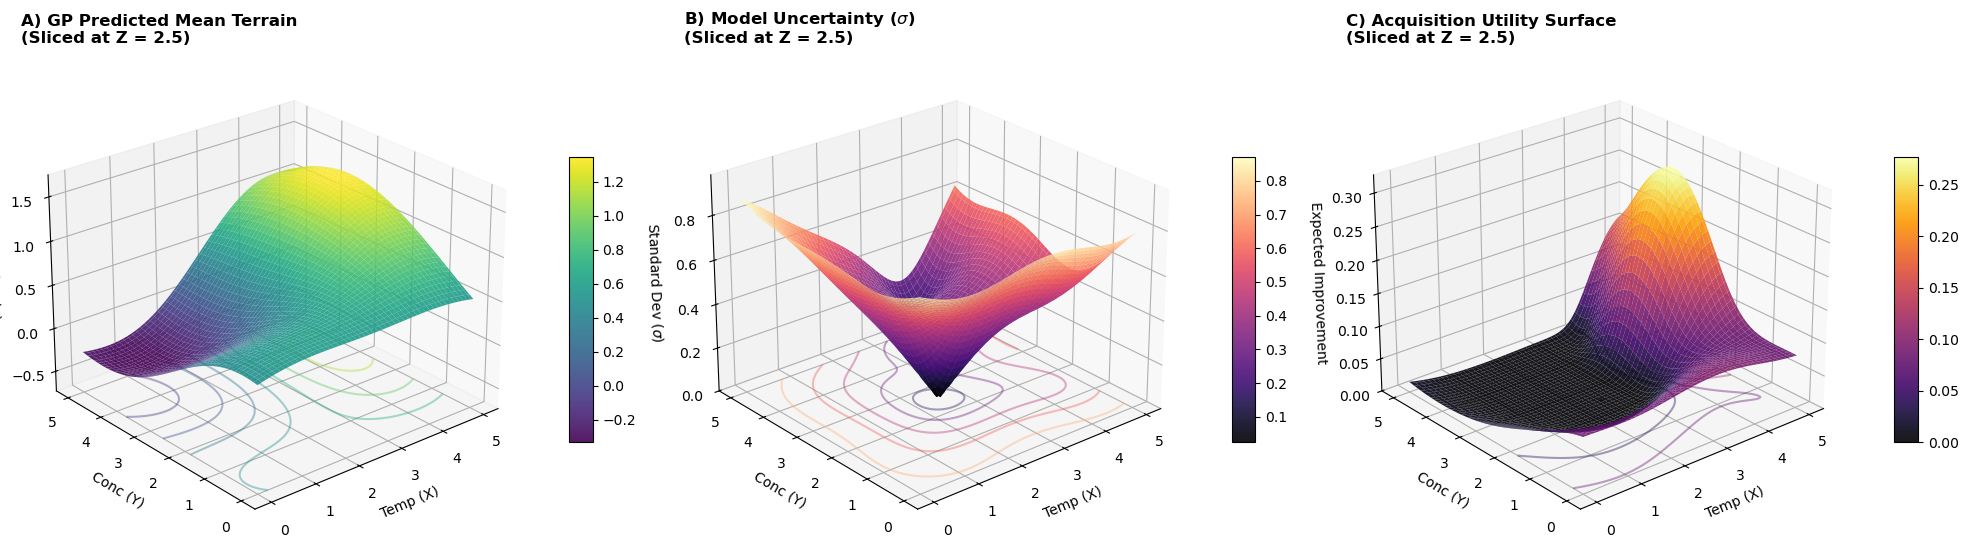

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. DEFINE THE 3D TRUE OBJECTIVE FUNCTION (3 inputs -> 1 output)
def true_func_3d(X, Y, Z):
    # E.g., Reaction Yield based on X=Temp, Y=Conc, Z=Time
    return np.sin(X) * np.cos(Y) + np.sin(Z / 2)

# 2. UNIVERSAL KERNEL (Works for 1D, 2D, 3D, etc.)
def rbf_kernel_universal(X1, X2, l=1.5, sigma_f=1.0):
    dist_matrix = np.sum(X1**2, 1).reshape(-1, 1) + np.sum(X2**2, 1) - 2 * np.dot(X1, X2.T)
    return sigma_f**2 * np.exp(-0.5 / l**2 * dist_matrix)

# 3. GAUSSIAN PROCESS POSTERIOR
def gp_prediction_3d(X_train, y_train, X_test, l=1.8, sigma_f=1.0, sigma_n=1e-4):
    K = rbf_kernel_universal(X_train, X_train, l, sigma_f) + sigma_n**2 * np.eye(len(X_train))
    K_s = rbf_kernel_universal(X_train, X_test, l, sigma_f)
    K_ss = rbf_kernel_universal(X_test, X_test, l, sigma_f) + 1e-8 * np.eye(len(X_test))
    
    K_inv = np.linalg.inv(K)
    mu_s = K_s.T.dot(K_inv).dot(y_train)
    cov_s = K_ss - K_s.T.dot(K_inv).dot(K_s)
    
    return mu_s.flatten(), np.sqrt(np.diag(cov_s))

# 4. EXPECTED IMPROVEMENT FOR THE SURFACE SLICE
def expected_improvement(mu, sigma, y_max, xi=0.01):
    sigma = np.maximum(sigma, 1e-9)
    improvement = mu - y_max - xi
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# =====================================================================
# DATA & INITIAL OBSERVATIONS SETUP
# =====================================================================
np.random.seed(42)

# 8 initial training points scattered in the 3D cube [X, Y, Z]
X_train = np.array([
    [1.0, 1.0, 1.0], [2.0, 4.0, 1.5], [4.5, 1.5, 3.5], [3.5, 4.5, 2.0],
    [1.5, 3.0, 4.5], [4.0, 3.0, 1.0], [2.5, 2.5, 2.5], [4.5, 4.5, 4.5]
])
y_train = true_func_3d(X_train[:, 0], X_train[:, 1], X_train[:, 2])

# =====================================================================
# GEOGRAPHIC SLICE MATRIX GENERATION
# =====================================================================
# Define a sharp 2D grid for X and Y variables
coord = np.linspace(0, 5, 100)
X_mesh, Y_mesh = np.meshgrid(coord, coord)

# Slice constant: Look at the horizontal terrain slicing through Z = 2.5
fixed_z = 2.5 
Z_slice = np.full(X_mesh.ravel().shape, fixed_z)

# Combine into a flat evaluation array [X, Y, Z_fixed]
X_test_slice = np.vstack([X_mesh.ravel(), Y_mesh.ravel(), Z_slice]).T

# Run predictions and optimization metrics on this specific slice
mu, sigma = gp_prediction_3d(X_train, y_train, X_test_slice)
y_max = np.max(y_train)
ei = expected_improvement(mu, sigma, y_max)

# Reshape the vector arrays back into smooth 2D surface grids
mu_surface = mu.reshape(X_mesh.shape)
sigma_surface = sigma.reshape(X_mesh.shape)
ei_surface = ei.reshape(X_mesh.shape)

# =====================================================================
# THREE-PANEL 3D GEOGRAPHIC SURFACE PLOTTING
# =====================================================================
fig = plt.figure(figsize=(20, 6))

# Define matching perspective camera parameters (elevation, azimuth)
elev_angle = 25
azim_angle = -130

# Plot 1: GP Predicted Mean Terrain
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
surf1 = ax1.plot_surface(X_mesh, Y_mesh, mu_surface, cmap='viridis', 
                         linewidth=0, antialiased=True, alpha=0.9)
ax1.contour(X_mesh, Y_mesh, mu_surface, zdir='z', offset=np.min(mu_surface)-0.4, cmap='viridis', alpha=0.4)
ax1.set_title(f'A) GP Predicted Mean Terrain\n(Sliced at Z = {fixed_z})', fontsize=12, fontweight='bold', loc='left')
ax1.set_xlabel('Temp (X)')
ax1.set_ylabel('Conc (Y)')
ax1.set_zlabel('Yield % ($\mu$)')
ax1.set_zlim(np.min(mu_surface)-0.4, np.max(mu_surface)+0.4)
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=12, pad=0.08)

# Plot 2: Model Uncertainty Surface
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
surf2 = ax2.plot_surface(X_mesh, Y_mesh, sigma_surface, cmap='magma', 
                         linewidth=0, antialiased=True, alpha=0.9)
ax2.contour(X_mesh, Y_mesh, sigma_surface, zdir='z', offset=0, cmap='magma', alpha=0.4)
ax2.set_title(f'B) Model Uncertainty ($\sigma$)\n(Sliced at Z = {fixed_z})', fontsize=12, fontweight='bold', loc='left')
ax2.set_xlabel('Temp (X)')
ax2.set_ylabel('Conc (Y)')
ax2.set_zlabel('Standard Dev ($\sigma$)')
ax2.set_zlim(0, np.max(sigma_surface)+0.1)
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=12, pad=0.08)

# Plot 3: Acquisition Function Surface (Utility Terrain)
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
surf3 = ax3.plot_surface(X_mesh, Y_mesh, ei_surface, cmap='inferno', 
                         linewidth=0, antialiased=True, alpha=0.9)
ax3.contour(X_mesh, Y_mesh, ei_surface, zdir='z', offset=0, cmap='inferno', alpha=0.4)
ax3.set_title(f'C) Acquisition Utility Surface\n(Sliced at Z = {fixed_z})', fontsize=12, fontweight='bold', loc='left')
ax3.set_xlabel('Temp (X)')
ax3.set_ylabel('Conc (Y)')
ax3.set_zlabel('Expected Improvement')
ax3.set_zlim(0, np.max(ei_surface)+0.05)
fig.colorbar(surf3, ax=ax3, shrink=0.5, aspect=12, pad=0.08)

# Synchronize viewing perspective angles across all three subplots
ax1.view_init(elev=elev_angle, azim=azim_angle)
ax2.view_init(elev=elev_angle, azim=azim_angle)
ax3.view_init(elev=elev_angle, azim=azim_angle)

plt.tight_layout()
plt.show()
